In [ ]:
%pip install -q kaggle
%pip install torch torchvision timm matplotlib

In [2]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dhanushalok","key":"06387013f15976e263411a6d2823ae91"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset
!unzip -qq tuberculosis-tb-chest-xray-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
 99% 658M/663M [00:07<00:00, 222MB/s]
100% 663M/663M [00:07<00:00, 94.5MB/s]


In [13]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_path = "/content/TB_Chest_Radiography_Database"

Device: cuda


In [14]:
gan_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

gan_dataset = ImageFolder(data_path, transform=gan_transform)
gan_loader = DataLoader(gan_dataset, batch_size=32, shuffle=True)

In [15]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, nz=100):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz,512,4,1,0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )
    def forward(self,x): return self.main(x)

In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512,1,4,1,0),
            nn.Sigmoid()
        )
    def forward(self,x): return self.main(x).view(-1,1)

In [19]:
images, _ = next(iter(gan_loader))
images = images.to(device)

out = netD(images)
print(out.shape)

torch.Size([32, 1])


In [ ]:
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
optD = torch.optim.Adam(netD.parameters(), lr=2e-4, betas=(0.5,0.999))
optG = torch.optim.Adam(netG.parameters(), lr=2e-4, betas=(0.5,0.999))

for epoch in range(15):
    for images, _ in gan_loader:

        images = images.to(device)
        batch_size = images.size(0)

        real_label = torch.ones(batch_size, device=device)
        fake_label = torch.zeros(batch_size, device=device)


        netD.zero_grad()

        # Real images
        output_real = netD(images).view(-1)
        lossD_real = criterion(output_real, real_label)

        # Fake images
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        fake_images = netG(noise)

        output_fake = netD(fake_images.detach()).view(-1)
        lossD_fake = criterion(output_fake, fake_label)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optD.step()

        netG.zero_grad()

        output_fake_for_G = netD(fake_images).view(-1)
        lossG = criterion(output_fake_for_G, real_label)

        lossG.backward()
        optG.step()

    print(f"Epoch {epoch+1} | LossD: {lossD.item():.4f} | LossG: {lossG.item():.4f}")

Epoch 1 | LossD: 0.9230 | LossG: 8.2431
Epoch 2 | LossD: 0.2014 | LossG: 1.8505
Epoch 3 | LossD: 0.5129 | LossG: 3.5677
Epoch 4 | LossD: 0.7176 | LossG: 1.3794
Epoch 5 | LossD: 0.8279 | LossG: 1.6492
Epoch 6 | LossD: 0.6457 | LossG: 2.4955
Epoch 7 | LossD: 0.2695 | LossG: 3.5077
Epoch 8 | LossD: 0.2855 | LossG: 3.6827
Epoch 9 | LossD: 1.7000 | LossG: 0.5831
Epoch 10 | LossD: 0.8492 | LossG: 6.0584
Epoch 11 | LossD: 1.2581 | LossG: 0.7961
Epoch 12 | LossD: 1.1974 | LossG: 0.7370
Epoch 13 | LossD: 0.3753 | LossG: 6.0689
Epoch 14 | LossD: 0.5071 | LossG: 7.4022
Epoch 15 | LossD: 1.0912 | LossG: 10.5623


In [22]:
cls_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

dataset = ImageFolder(data_path, transform=cls_transform)

train_idx, temp_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.3,
    stratify=dataset.targets,
    random_state=42
)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [23]:
model = models.densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 69.8MB/s]


In [24]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0816
Epoch 2, Loss: 0.0173
Epoch 3, Loss: 0.0075
Epoch 4, Loss: 0.0024
Epoch 5, Loss: 0.0041


In [25]:
torch.save(model.state_dict(), "best_densenet_tb.pth")

In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate model
model = models.densenet121(pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model.load_state_dict(torch.load("best_densenet_tb.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model Loaded Successfully ✅ Z")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model Loaded Successfully ✅


In [27]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy * 100, "%")
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))
print("\nConfusion Matrix:\n")
print(confusion_matrix(all_labels, all_preds))

Test Accuracy: 100.0 %

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       525
           1       1.00      1.00      1.00       105

    accuracy                           1.00       630
   macro avg       1.00      1.00      1.00       630
weighted avg       1.00      1.00      1.00       630


Confusion Matrix:

[[525   0]
 [  0 105]]


Prediction: Normal
Confidence: 99.63%


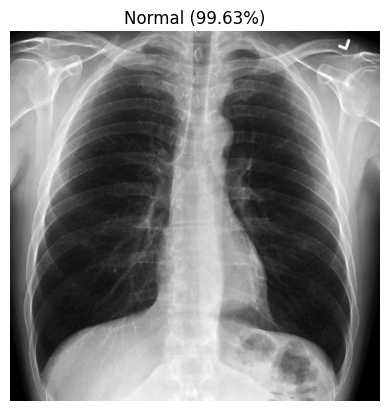

In [37]:
from PIL import Image
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt

image_path = "normal4.jpg" # automatically picks uploaded file

# SAME transform used during training
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

image = Image.open(image_path)
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = F.softmax(output, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

classes = ["Normal", "Tuberculosis"]

predicted_class = classes[predicted.item()]
confidence_score = confidence.item() * 100

print("Prediction:", predicted_class)
print(f"Confidence: {confidence_score:.2f}%")

plt.imshow(image, cmap="gray")
plt.title(f"{predicted_class} ({confidence_score:.2f}%)")
plt.axis("off")
plt.show()